# Association Rule Mining

## 1. Market Basket Analysis Concept and Motivation

**Market basket analysis** is a data mining technique used to discover relationships between items that frequently co-occur in transactions. The classic example: a supermarket analyst notices that customers who buy diapers also tend to buy beer a counterintuitive but actionable insight.

### Why it matters
- **Retail**: product placement, cross-selling, bundle promotions
- **E-commerce**: "customers who bought X also bought Y"
- **Healthcare**: co-occurring symptoms or drug combinations
- **Web analytics**: pages visited together in a session
- **Fraud detection**: transactions that frequently occur together

### Formal problem definition
Given:
- A set of **items** $I = \{i_1, i_2, \ldots, i_m\}$
- A **database** of transactions $D = \{T_1, T_2, \ldots, T_n\}$ where each $T_k \subseteq I$

Find all **association rules** $A \Rightarrow B$ where $A, B \subseteq I$ and $A \cap B = \emptyset$, such that the rules satisfy minimum **support** and **confidence** thresholds.

An **itemset** is any subset of $I$. A **frequent itemset** is one whose support exceeds the minimum threshold $\sigma$.

## 2. Key Metrics

### 2.1 Support
The fraction of transactions containing both $A$ and $B$:

$$\text{support}(A \Rightarrow B) = \frac{|A \cup B|}{|N|}$$

where $|A \cup B|$ is the number of transactions containing all items in $A$ and $B$, and $|N|$ is the total number of transactions.

> **Interpretation**: How often this itemset appears in the dataset. Low support → rare rule.

---

### 2.2 Confidence
The conditional probability that $B$ is purchased given $A$ is purchased:

$$\text{confidence}(A \Rightarrow B) = \frac{|A \cup B|}{|A|}$$

> **Interpretation**: Among transactions containing $A$, what fraction also contain $B$? High confidence means strong implication.

---

### 2.3 Lift
How much more likely $B$ is purchased when $A$ is purchased, compared to $B$'s baseline frequency:

$$\text{lift}(A \Rightarrow B) = \frac{\text{confidence}(A \Rightarrow B)}{\text{support}(B)}$$

- $\text{lift} > 1$: positive association (buying $A$ increases likelihood of $B$)
- $\text{lift} = 1$: independence
- $\text{lift} < 1$: negative association

---

### 2.4 Leverage
The difference between observed co-occurrence and expected co-occurrence under independence:

$$\text{leverage}(A \Rightarrow B) = \text{support}(A \Rightarrow B) - \text{support}(A) \times \text{support}(B)$$

- Leverage $= 0$: independent
- Leverage $> 0$: positively correlated
- Range: $[-1, 1]$

---

### 2.5 Conviction
Measures the degree to which $A$ implies $B$ (sensitive to rule direction, unlike lift):

$$\text{conviction}(A \Rightarrow B) = \frac{1 - \text{support}(B)}{1 - \text{confidence}(A \Rightarrow B)}$$

- $\text{conviction} = 1$: independence
- $\text{conviction} \rightarrow \infty$: perfect implication (confidence = 1)
- High conviction means $A$ is a strong predictor of $B$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------
# Manual metric calculations (no library)
# -----------------------------------------------------------
transactions = [
    ['milk', 'bread', 'butter'],
    ['milk', 'bread'],
    ['milk', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread', 'butter', 'eggs'],
    ['bread', 'eggs'],
    ['milk', 'eggs'],
    ['butter', 'eggs'],
    ['milk', 'bread', 'eggs'],
    ['bread', 'butter', 'eggs'],
]

N = len(transactions)

def get_support(itemset, transactions):
    count = sum(1 for t in transactions if set(itemset).issubset(set(t)))
    return count / len(transactions)

# Rule: {milk, bread} => {butter}
A = ['milk', 'bread']
B = ['butter']
AB = A + B

sup_A   = get_support(A, transactions)
sup_B   = get_support(B, transactions)
sup_AB  = get_support(AB, transactions)

confidence = sup_AB / sup_A
lift       = confidence / sup_B
leverage   = sup_AB - sup_A * sup_B
conviction = (1 - sup_B) / (1 - confidence) if confidence < 1 else float('inf')

print(f"Rule: {{milk, bread}} => {{butter}}")
print(f"  support(A)     = {sup_A:.3f}")
print(f"  support(B)     = {sup_B:.3f}")
print(f"  support(A∪B)   = {sup_AB:.3f}")
print(f"  confidence     = {confidence:.3f}")
print(f"  lift           = {lift:.3f}")
print(f"  leverage       = {leverage:.3f}")
print(f"  conviction     = {conviction:.3f}")

Rule: {milk, bread} => {butter}
  support(A)     = 0.400
  support(B)     = 0.600
  support(A∪B)   = 0.200
  confidence     = 0.500
  lift           = 0.833
  leverage       = -0.040
  conviction     = 0.800


## 3. Apriori Algorithm

The **Apriori** algorithm (Agrawal & Srikant, 1994) is the foundational frequent itemset mining algorithm. It exploits the **anti-monotone property** of support:

> **Apriori principle**: If an itemset is frequent, then all of its subsets must also be frequent. Equivalently, if an itemset is *infrequent*, all of its supersets are infrequent.

### Algorithm steps

1. **Scan** the database to find all frequent 1-itemsets $L_1$ (items above min_support)
2. **Generate** candidate $k$-itemsets $C_k$ by joining $(k-1)$-itemsets from $L_{k-1}$
3. **Prune** candidates: remove any $C_k$ where a $(k-1)$-subset is not in $L_{k-1}$
4. **Scan** database to count support of remaining candidates → $L_k$
5. Repeat until no new frequent itemsets are found

### Complexity
- Multiple database scans: $O(|L_{k-1}|^2)$ candidate generation per level
- Memory: must store all candidates $C_k$ in memory
- **Bottleneck**: repeated full database scans

### Candidate generation (join step)
Two itemsets $p, q \in L_{k-1}$ are joined if they share the same first $k-2$ items:

$$p = \{i_1, i_2, \ldots, i_{k-2}, i_{k-1}\}, \quad q = \{i_1, i_2, \ldots, i_{k-2}, i_k\}$$
$$\Rightarrow C_k \ni \{i_1, i_2, \ldots, i_{k-2}, i_{k-1}, i_k\}$$

In [2]:
# -----------------------------------------------------------
# Apriori from scratch (educational)
# -----------------------------------------------------------
from itertools import combinations
from collections import defaultdict

def apriori_scratch(transactions, min_support=0.3):
    """Simple Apriori implementation for illustration."""
    n = len(transactions)
    items = sorted(set(item for t in transactions for item in t))
    
    # k=1: frequent single items
    freq_sets = {}
    L_prev = []
    for item in items:
        sup = get_support([item], transactions)
        if sup >= min_support:
            freq_sets[frozenset([item])] = sup
            L_prev.append(frozenset([item]))
    
    k = 2
    while L_prev:
        # Generate candidates
        candidates = set()
        for i, p in enumerate(L_prev):
            for j, q in enumerate(L_prev):
                if j > i:
                    union = p | q
                    if len(union) == k:
                        # Prune: check all (k-1)-subsets are frequent
                        subsets = [frozenset(s) for s in combinations(union, k-1)]
                        if all(s in freq_sets for s in subsets):
                            candidates.add(union)
        
        L_curr = []
        for cand in candidates:
            sup = get_support(list(cand), transactions)
            if sup >= min_support:
                freq_sets[cand] = sup
                L_curr.append(cand)
        
        L_prev = L_curr
        k += 1
    
    return freq_sets

frequent = apriori_scratch(transactions, min_support=0.3)
print(f"Found {len(frequent)} frequent itemsets (min_support=0.3):\n")
for itemset, sup in sorted(frequent.items(), key=lambda x: (-len(x[0]), -x[1])):
    print(f"  {str(set(itemset)):<35} support = {sup:.2f}")

Found 10 frequent itemsets (min_support=0.3):

  {'eggs', 'bread'}                   support = 0.40
  {'milk', 'bread'}                   support = 0.40
  {'butter', 'bread'}                 support = 0.40
  {'butter', 'milk'}                  support = 0.30
  {'eggs', 'milk'}                    support = 0.30
  {'eggs', 'butter'}                  support = 0.30
  {'bread'}                           support = 0.70
  {'butter'}                          support = 0.60
  {'eggs'}                            support = 0.60
  {'milk'}                            support = 0.60


In [3]:
# -----------------------------------------------------------
# Apriori with mlxtend on grocery dataset
# -----------------------------------------------------------
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Encode transactions into one-hot DataFrame
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print("One-hot encoded transaction matrix:")
print(df.to_string())

# Run Apriori
frequent_itemsets = apriori(df, min_support=0.3, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"\nFrequent itemsets found: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values(['length', 'support'], ascending=[True, False]).to_string(index=False))

# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)
print(f"\nAssociation rules (lift >= 1.0): {len(rules)}")
print(rules[['antecedents','consequents','support','confidence','lift','leverage','conviction']]
      .round(3).to_string(index=False))

One-hot encoded transaction matrix:
   bread  butter   eggs   milk
0   True    True  False   True
1   True   False  False   True
2  False    True  False   True
3   True    True  False  False
4   True    True   True   True
5   True   False   True  False
6  False   False   True   True
7  False    True   True  False
8   True   False   True   True
9   True    True   True  False

Frequent itemsets found: 10
 support                   itemsets  length
     0.7         frozenset({bread})       1
     0.6        frozenset({butter})       1
     0.6          frozenset({eggs})       1
     0.6          frozenset({milk})       1
     0.4 frozenset({butter, bread})       2
     0.4   frozenset({eggs, bread})       2
     0.4   frozenset({milk, bread})       2
     0.3  frozenset({eggs, butter})       2
     0.3  frozenset({butter, milk})       2
     0.3    frozenset({eggs, milk})       2

Association rules (lift >= 1.0): 0
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, l

## 4. FP-Growth Algorithm

**FP-Growth** (Han et al., 2000) overcomes Apriori's bottleneck by compressing the database into a **Frequent Pattern Tree (FP-tree)** a compact prefix-tree structure and mining it directly without candidate generation.

### FP-Tree construction
1. **First scan**: count item frequencies, discard infrequent items, sort frequent items by descending frequency
2. **Second scan**: for each transaction, insert the sorted frequent items into the tree (sharing prefixes)
3. Each node stores: item name, count, parent pointer, and child pointers
4. A **header table** maintains linked lists across all nodes of each item

### Mining the FP-Tree
For each item $i$ (in ascending frequency order):
1. Construct the **conditional pattern base** (prefix paths ending at $i$)
2. Build the **conditional FP-tree** from the pattern base
3. Recursively mine the conditional FP-tree

### Complexity advantage
- Only **2 database scans** (vs. multiple in Apriori)
- No candidate generation
- Tree is often much smaller than raw database due to prefix sharing
- Time complexity: $O(|D| \cdot \bar{l})$ where $\bar{l}$ is average transaction length

### FP-Tree node structure
```
Node:
  item_name  : str
  count      : int       # support count through this path
  parent     : Node
  children   : dict      # item -> Node
  node_link  : Node      # horizontal link to next same-item node
```

In [4]:
# -----------------------------------------------------------
# FP-Growth with mlxtend
# -----------------------------------------------------------
from mlxtend.frequent_patterns import fpgrowth

# FP-Growth on the same encoded DataFrame
fp_itemsets = fpgrowth(df, min_support=0.3, use_colnames=True)
fp_itemsets['length'] = fp_itemsets['itemsets'].apply(len)
fp_itemsets_sorted = fp_itemsets.sort_values(['length', 'support'], ascending=[True, False])

print("FP-Growth frequent itemsets:")
print(fp_itemsets_sorted.to_string(index=False))

# Compare with Apriori
apriori_set = set(frozenset(r) for r in frequent_itemsets['itemsets'])
fpgrowth_set = set(frozenset(r) for r in fp_itemsets['itemsets'])
print(f"\nApriori found:   {len(apriori_set)} itemsets")
print(f"FP-Growth found: {len(fpgrowth_set)} itemsets")
print(f"Sets are identical: {apriori_set == fpgrowth_set}")

# Generate rules from FP-Growth results
fp_rules = association_rules(fp_itemsets, metric='confidence', min_threshold=0.5)
fp_rules = fp_rules.sort_values('lift', ascending=False)
print(f"\nFP-Growth rules (confidence >= 0.5):")
print(fp_rules[['antecedents','consequents','support','confidence','lift']]
      .round(3).to_string(index=False))

FP-Growth frequent itemsets:
 support                   itemsets  length
     0.7         frozenset({bread})       1
     0.6          frozenset({milk})       1
     0.6        frozenset({butter})       1
     0.6          frozenset({eggs})       1
     0.4   frozenset({milk, bread})       2
     0.4 frozenset({butter, bread})       2
     0.4   frozenset({eggs, bread})       2
     0.3  frozenset({butter, milk})       2
     0.3  frozenset({eggs, butter})       2
     0.3    frozenset({eggs, milk})       2

Apriori found:   10 itemsets
FP-Growth found: 10 itemsets
Sets are identical: True

FP-Growth rules (confidence >= 0.5):
        antecedents         consequents  support  confidence  lift
  frozenset({milk})  frozenset({bread})      0.4       0.667 0.952
 frozenset({bread})   frozenset({milk})      0.4       0.571 0.952
frozenset({butter})  frozenset({bread})      0.4       0.667 0.952
 frozenset({bread}) frozenset({butter})      0.4       0.571 0.952
 frozenset({bread})   frozense

In [5]:
# -----------------------------------------------------------
# FP-Tree visualization (manual construction)
# -----------------------------------------------------------
from collections import Counter

class FPNode:
    def __init__(self, name, count=0, parent=None):
        self.name = name
        self.count = count
        self.parent = parent
        self.children = {}
        self.link = None
    def __repr__(self):
        return f"FPNode({self.name}:{self.count})"

def build_fp_tree(transactions, min_support=0.3):
    n = len(transactions)
    min_count = int(min_support * n)
    
    # First scan: count items
    item_counts = Counter(item for t in transactions for item in t)
    freq_items = {item: cnt for item, cnt in item_counts.items() if cnt >= min_count}
    
    # Header table
    header = {item: None for item in freq_items}
    root = FPNode('root')
    
    def update_link(header, item, node):
        if header[item] is None:
            header[item] = node
        else:
            curr = header[item]
            while curr.link:
                curr = curr.link
            curr.link = node
    
    # Second scan: build tree
    for t in transactions:
        sorted_t = sorted([i for i in t if i in freq_items],
                          key=lambda x: -freq_items[x])
        curr = root
        for item in sorted_t:
            if item in curr.children:
                curr.children[item].count += 1
            else:
                new_node = FPNode(item, 1, curr)
                curr.children[item] = new_node
                update_link(header, item, new_node)
            curr = curr.children[item]
    
    return root, header, freq_items

def print_tree(node, indent=0):
    if node.name != 'root':
        print('  ' * indent + f"{node.name}:{node.count}")
    for child in node.children.values():
        print_tree(child, indent + 1)

root, header, freq_items = build_fp_tree(transactions, min_support=0.3)
print("FP-Tree structure (item:count):")
print("root")
print_tree(root)
print(f"\nHeader table (item: frequency):")
for item, cnt in sorted(freq_items.items(), key=lambda x: -x[1]):
    print(f"  {item}: {cnt}")

FP-Tree structure (item:count):
root
  bread:7
    milk:4
      butter:2
        eggs:1
      eggs:1
    butter:2
      eggs:1
    eggs:1
  milk:2
    butter:1
    eggs:1
  butter:1
    eggs:1

Header table (item: frequency):
  bread: 7
  milk: 6
  butter: 6
  eggs: 6


## 5. ECLAT Equivalence Class Transformation

**ECLAT** (Zaki et al., 1997) uses a **vertical data format** instead of the horizontal transaction list used by Apriori and FP-Growth.

### Vertical format: Tidsets
Instead of storing transactions as lists of items, ECLAT stores each item as its **tidset** (transaction ID set):

$$\text{tidset}(X) = \{t \in D \mid X \subseteq t\}$$

The support of an itemset $X$ is simply:
$$\text{support}(X) = \frac{|\text{tidset}(X)|}{|D|}$$

### Joining itemsets via tidset intersection
To compute the support of $X \cup Y$:
$$\text{tidset}(X \cup Y) = \text{tidset}(X) \cap \text{tidset}(Y)$$

This **eliminates database scans** entirely after the initial tidset construction.

### Equivalence classes
ECLAT partitions itemsets into equivalence classes based on common prefixes. Items in the same class share a $(k-1)$-length prefix and are joined pairwise:

$$[P] = \{Pi, Pj, Pk, \ldots\} \Rightarrow \text{join } Pi \text{ with } Pj: \text{tidset}(Pij) = \text{tidset}(Pi) \cap \text{tidset}(Pj)$$

### Complexity
- Tidset intersection is fast: $O(|\text{tidset}|)$
- Memory: tidsets can be large for frequent items (diffset optimization helps)
- Faster than Apriori in practice for dense datasets

In [6]:
# -----------------------------------------------------------
# ECLAT from scratch
# -----------------------------------------------------------

def eclat(transactions, min_support=0.3):
    """
    ECLAT algorithm using vertical tidset representation.
    Returns dict of frozenset -> support.
    """
    n = len(transactions)
    min_count = int(min_support * n)
    
    # Step 1: Build vertical database (item -> tidset)
    vertical_db = defaultdict(set)
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            vertical_db[item].add(tid)
    
    # Keep only frequent 1-itemsets
    vertical_db = {frozenset([item]): tids
                   for item, tids in vertical_db.items()
                   if len(tids) >= min_count}
    
    freq_itemsets = {k: len(v)/n for k, v in vertical_db.items()}
    
    def eclat_recursive(prefix_items):
        """Recursively mine equivalence classes."""
        items = list(prefix_items.items())
        for i in range(len(items)):
            itemset_i, tidset_i = items[i]
            new_prefix = {}
            for j in range(i + 1, len(items)):
                itemset_j, tidset_j = items[j]
                # Intersect tidsets
                new_tidset = tidset_i & tidset_j
                if len(new_tidset) >= min_count:
                    new_itemset = itemset_i | itemset_j
                    freq_itemsets[new_itemset] = len(new_tidset) / n
                    new_prefix[new_itemset] = new_tidset
            if new_prefix:
                eclat_recursive(new_prefix)
    
    eclat_recursive(vertical_db)
    return freq_itemsets

eclat_results = eclat(transactions, min_support=0.3)
print(f"ECLAT found {len(eclat_results)} frequent itemsets:\n")
for itemset, sup in sorted(eclat_results.items(), key=lambda x: (-len(x[0]), -x[1])):
    print(f"  {str(set(itemset)):<35} support = {sup:.2f}")

# Verify against Apriori
eclat_set = set(eclat_results.keys())
print(f"\nECLAT == Apriori: {eclat_set == apriori_set}")

ECLAT found 10 frequent itemsets:

  {'milk', 'bread'}                   support = 0.40
  {'butter', 'bread'}                 support = 0.40
  {'eggs', 'bread'}                   support = 0.40
  {'butter', 'milk'}                  support = 0.30
  {'eggs', 'milk'}                    support = 0.30
  {'eggs', 'butter'}                  support = 0.30
  {'bread'}                           support = 0.70
  {'milk'}                            support = 0.60
  {'butter'}                          support = 0.60
  {'eggs'}                            support = 0.60

ECLAT == Apriori: True


## 6. SPADE Sequential Pattern Mining

**SPADE** (Sequential PAttern Discovery using Equivalence classes, Zaki 2001) extends ECLAT to mine **sequential patterns** ordered sequences of itemsets that appear across time.

### Sequence database
A **sequence** is an ordered list of itemsets (events): $s = \langle e_1, e_2, \ldots, e_k \rangle$ where each $e_i$ is an itemset occurring at time $t_i < t_{i+1}$.

A sequence $\alpha$ is a **subsequence** of $\beta$ if all events of $\alpha$ appear in $\beta$ in order (not necessarily contiguous).

### ID-lists (vertical format for sequences)
Each sequence $\alpha$ maps to a list of $(\text{sid}, \text{eid})$ pairs:
- **sid**: sequence ID (customer)
- **eid**: event ID (timestamp/position)

$$\mathcal{L}(\alpha) = \{(s, e) \mid \alpha \text{ ends at event } e \text{ in sequence } s\}$$

### Join operations
SPADE uses two types of joins:
1. **Temporal join** (sequence extension): $\alpha = \langle \ldots, a \rangle$ and $\beta = \langle \ldots, b \rangle$ → $\langle \ldots, a, b \rangle$ (b follows a)
2. **Itemset join** (itemset extension): extend last event → $\langle \ldots, \{a, b\} \rangle$

Support is computed via ID-list joins (similar to ECLAT tidset intersection).

### Applications
- Customer purchase sequences (what do customers buy next?)
- Web clickstream analysis
- Medical event sequences (disease progression)
- Log analysis

In [7]:
# -----------------------------------------------------------
# SPADE-like sequential pattern mining (simplified)
# -----------------------------------------------------------

# Sequence database: each entry is (customer_id, [(timestamp, items)])
sequence_db = [
    # customer 0
    [(1, ['milk', 'bread']), (2, ['butter']), (3, ['eggs'])],
    # customer 1
    [(1, ['milk']), (2, ['bread', 'butter']), (4, ['eggs'])],
    # customer 2
    [(1, ['bread']), (3, ['milk', 'eggs'])],
    # customer 3
    [(1, ['milk', 'bread']), (2, ['eggs'])],
    # customer 4
    [(1, ['butter']), (2, ['milk']), (3, ['bread']), (4, ['eggs'])],
    # customer 5
    [(1, ['milk', 'butter']), (2, ['bread']), (3, ['eggs'])],
]

def check_subsequence(pattern, sequence):
    """Check if pattern (list of itemsets) is a subsequence of sequence."""
    events = [set(items) for _, items in sequence]
    pat_idx = 0
    for event in events:
        if set(pattern[pat_idx]).issubset(event):
            pat_idx += 1
            if pat_idx == len(pattern):
                return True
    return False

def seq_support(pattern, seq_db):
    count = sum(1 for seq in seq_db if check_subsequence(pattern, seq))
    return count / len(seq_db)

# Mine frequent 1-sequences
all_items = sorted(set(item for seq in sequence_db
                       for _, items in seq for item in items))

min_sup = 0.5
print(f"Sequential patterns (min_support={min_sup}):\n")

freq_1_seqs = []
for item in all_items:
    sup = seq_support([[item]], sequence_db)
    if sup >= min_sup:
        freq_1_seqs.append([item])
        print(f"  <{[item]}> support = {sup:.3f}")

# Mine frequent 2-sequences
print("\nFrequent 2-sequences (A then B):")
for a in freq_1_seqs:
    for b in freq_1_seqs:
        if a != b:
            pattern = [a, b]
            sup = seq_support(pattern, sequence_db)
            if sup >= min_sup:
                print(f"  <{a} -> {b}> support = {sup:.3f}")

Sequential patterns (min_support=0.5):

  <['bread']> support = 1.000
  <['butter']> support = 0.667
  <['eggs']> support = 1.000
  <['milk']> support = 1.000

Frequent 2-sequences (A then B):
  <['bread'] -> ['eggs']> support = 1.000
  <['butter'] -> ['eggs']> support = 0.667
  <['milk'] -> ['bread']> support = 0.500
  <['milk'] -> ['eggs']> support = 0.833


## 7. PrefixSpan Prefix-Projected Databases

**PrefixSpan** (Pei et al., 2001) is the leading sequential pattern mining algorithm. It avoids explicit candidate generation by using **prefix projections** projecting the database onto suffixes after each prefix.

### Core idea
For a prefix $\alpha$, the **$\alpha$-projected database** $D|_\alpha$ contains only the suffixes of sequences that contain $\alpha$:

$$D|_\alpha = \{\text{suffix}(s, \alpha) \mid s \in D, \alpha \sqsubseteq s\}$$

### Algorithm
```
PrefixSpan(prefix α, D|α, min_sup):
  1. Find all frequent items i in D|α
  2. For each frequent item i:
     a. Append i to α → α' (either extend last event or start new event)
     b. Output α' as a frequent sequential pattern
     c. Construct D|α' (project database on α')
     d. Recursively call PrefixSpan(α', D|α', min_sup)
```

### Projection types
- **i-extension**: item $i$ is appended to the last event of prefix (same timestamp)
- **s-extension**: item $i$ starts a new event after the prefix (new timestamp)

### Advantages over SPADE
- No explicit ID-list joins
- Projected databases shrink recursively → fast
- Memory-efficient: no need to store all candidates
- Scales well with database size and pattern length

In [8]:
# -----------------------------------------------------------
# PrefixSpan (simplified, s-extension only for clarity)
# -----------------------------------------------------------

def project_database(seq_db, prefix_item):
    """
    Project database: for each sequence, find suffix after first
    occurrence of prefix_item as a new event.
    """
    projected = []
    for seq in seq_db:
        for idx, (ts, items) in enumerate(seq):
            if prefix_item in items:
                # suffix starts from next event
                suffix = seq[idx+1:]
                if suffix:
                    projected.append(suffix)
                break
    return projected

def count_items_in_db(seq_db):
    counts = Counter()
    for seq in seq_db:
        seen = set()
        for _, items in seq:
            for item in items:
                if item not in seen:
                    counts[item] += 1
                    seen.add(item)
    return counts

def prefixspan(seq_db, min_sup_count, prefix=None, results=None):
    if results is None:
        results = []
    if prefix is None:
        prefix = []
    
    item_counts = count_items_in_db(seq_db)
    
    for item, count in sorted(item_counts.items()):
        if count >= min_sup_count:
            new_prefix = prefix + [item]
            results.append((new_prefix, count))
            projected = project_database(seq_db, item)
            if projected:
                prefixspan(projected, min_sup_count, new_prefix, results)
    
    return results

n_seqs = len(sequence_db)
min_count = int(0.5 * n_seqs)
patterns = prefixspan(sequence_db, min_count)

print(f"PrefixSpan sequential patterns (min_support=0.5, n={n_seqs}):")
for pattern, count in sorted(patterns, key=lambda x: (len(x[0]), x[0])):
    sup = count / n_seqs
    print(f"  {' -> '.join(pattern):<30} support = {sup:.3f}  (count={count})")

PrefixSpan sequential patterns (min_support=0.5, n=6):
  bread                          support = 1.000  (count=6)
  butter                         support = 0.667  (count=4)
  eggs                           support = 1.000  (count=6)
  milk                           support = 1.000  (count=6)
  bread -> eggs                  support = 1.000  (count=6)
  butter -> eggs                 support = 0.667  (count=4)
  milk -> bread                  support = 0.500  (count=3)
  milk -> eggs                   support = 0.833  (count=5)
  milk -> bread -> eggs          support = 0.500  (count=3)


## 8. CHARM Closed Frequent Itemsets

**CHARM** (Zaki & Hsiao, 2002) mines **closed frequent itemsets** a condensed representation that is lossless yet much smaller than the full frequent itemset collection.

### Closed itemsets
An itemset $X$ is **closed** if there is no proper superset $Y \supset X$ with the same support:

$$X \text{ is closed} \iff \nexists Y \supset X : \text{support}(Y) = \text{support}(X)$$

### Why closed itemsets?
- The set of closed frequent itemsets is a **lossless compression** of all frequent itemsets
- Any non-closed frequent itemset $X$ has a superset with identical support → $X$ is redundant
- Dramatically reduces output size (especially in dense datasets)
- All association rules can be derived from closed itemsets without loss

### Galois connection
CHARM uses a **Galois closure operator** based on tidsets:
$$h(X) = \bigcap_{t \in \mathcal{L}(X)} t \quad \text{(items common to all transactions containing X)}$$

An itemset $X$ is closed iff $h(\mathcal{L}(X)) = X$.

### CHARM-extend procedure
Uses four properties to prune the search space during itemset/tidset pair enumeration:
1. $\mathcal{L}(X) = \mathcal{L}(Y)$: replace $X$ by $X \cup Y$ everywhere
2. $\mathcal{L}(X) \subset \mathcal{L}(Y)$: replace $X$ by $X \cup Y$, keep $Y$
3. $\mathcal{L}(X) \supset \mathcal{L}(Y)$: keep $X$, process $X \cup Y$
4. $\mathcal{L}(X) \neq \mathcal{L}(Y)$: process $X \cup Y$ with $\mathcal{L}(X) \cap \mathcal{L}(Y)$

In [9]:
# -----------------------------------------------------------
# CHARM: closed frequent itemsets
# -----------------------------------------------------------

def charm(transactions, min_support=0.3):
    """
    Simplified CHARM algorithm.
    Returns dict: frozenset(itemset) -> support
    """
    n = len(transactions)
    min_count = int(min_support * n)
    
    # Build vertical database
    vertical = defaultdict(set)
    for tid, t in enumerate(transactions):
        for item in t:
            vertical[item].add(tid)
    
    # Keep frequent 1-itemsets
    pairs = {frozenset([item]): tids
             for item, tids in vertical.items()
             if len(tids) >= min_count}
    
    closed = {}
    
    def is_subsumed(itemset, support, closed):
        """Check if a closed superset with same support already exists."""
        for closed_set, closed_sup in closed.items():
            if closed_sup == support and itemset.issubset(closed_set):
                return True
        return False
    
    def charm_extend(p_pairs):
        items = sorted(p_pairs.keys(), key=lambda x: len(p_pairs[x]))
        for i, Xi in enumerate(items):
            Xi_tids = p_pairs[Xi]
            new_p = {}
            Xi_new = Xi  # may grow
            
            for j, Xj in enumerate(items):
                if j <= i:
                    continue
                Xj_tids = p_pairs[Xj]
                union_tids = Xi_tids & Xj_tids
                
                if len(union_tids) < min_count:
                    continue
                
                union_set = Xi_new | Xj
                
                if Xi_tids == Xj_tids:
                    # Property 1: same tidset → replace Xi with union
                    Xi_new = union_set
                    # Remove Xj from future processing
                elif Xi_tids < Xj_tids:
                    # Property 2: Xi's tidset is subset → replace Xi
                    Xi_new = union_set
                    new_p[union_set] = union_tids
                else:
                    # Property 3 or 4
                    new_p[union_set] = union_tids
            
            # Check if Xi_new is closed
            sup = len(Xi_tids) / n
            if not is_subsumed(Xi_new, sup, closed):
                closed[Xi_new] = sup
            
            if new_p:
                charm_extend(new_p)
    
    charm_extend(pairs)
    return closed

closed_itemsets = charm(transactions, min_support=0.3)
all_freq = eclat(transactions, min_support=0.3)

print(f"All frequent itemsets (ECLAT):   {len(all_freq)}")
print(f"Closed frequent itemsets (CHARM): {len(closed_itemsets)}")
print(f"Compression ratio: {len(closed_itemsets)/len(all_freq):.1%}\n")
print("Closed frequent itemsets:")
for itemset, sup in sorted(closed_itemsets.items(), key=lambda x: (-len(x[0]), -x[1])):
    print(f"  {str(set(itemset)):<40} support = {sup:.2f}")

All frequent itemsets (ECLAT):   10
Closed frequent itemsets (CHARM): 10
Compression ratio: 100.0%

Closed frequent itemsets:
  {'milk', 'bread'}                        support = 0.40
  {'butter', 'bread'}                      support = 0.40
  {'eggs', 'bread'}                        support = 0.40
  {'butter', 'milk'}                       support = 0.30
  {'eggs', 'milk'}                         support = 0.30
  {'eggs', 'butter'}                       support = 0.30
  {'bread'}                                support = 0.70
  {'milk'}                                 support = 0.60
  {'butter'}                               support = 0.60
  {'eggs'}                                 support = 0.60


## 9. Real Grocery Store Dataset with mlxtend

We now apply Apriori and FP-Growth to a realistic grocery dataset. We generate a synthetic but realistic dataset modeled after common grocery purchasing patterns.

In [10]:
# -----------------------------------------------------------
# Generate realistic grocery transactions
# -----------------------------------------------------------
import random
random.seed(42)
np.random.seed(42)

# Product categories with realistic co-purchase probabilities
basket_templates = [
    # (base items, extra items pool, probability of adding each extra)
    (['whole milk'], ['butter', 'yogurt', 'cream cheese', 'eggs'], 0.4),
    (['bread', 'butter'], ['jam', 'honey', 'whole milk', 'eggs'], 0.35),
    (['chicken'], ['rice', 'vegetables', 'olive oil', 'garlic', 'onion'], 0.45),
    (['pasta'], ['tomato sauce', 'parmesan', 'ground beef', 'olive oil'], 0.5),
    (['beer'], ['chips', 'salsa', 'frozen pizza', 'nuts'], 0.4),
    (['coffee'], ['sugar', 'cream', 'biscuits', 'whole milk'], 0.35),
    (['fruits'], ['yogurt', 'granola', 'honey', 'nuts'], 0.3),
    (['diapers'], ['baby food', 'wipes', 'beer', 'formula'], 0.45),
    (['shampoo'], ['conditioner', 'soap', 'toothpaste', 'razor'], 0.5),
    (['vegetables'], ['olive oil', 'garlic', 'onion', 'rice', 'chicken'], 0.4),
]

grocery_transactions = []
for _ in range(1000):
    template = random.choice(basket_templates)
    base, extras, prob = template
    basket = list(base)
    for extra in extras:
        if random.random() < prob:
            basket.append(extra)
    # Add a few random items
    all_items_flat = ['whole milk','bread','butter','eggs','chicken','rice',
                      'vegetables','pasta','tomato sauce','coffee','sugar',
                      'beer','chips','fruits','yogurt','olive oil','garlic',
                      'onion','shampoo','soap']
    n_random = np.random.poisson(1)
    basket += random.choices(all_items_flat, k=n_random)
    grocery_transactions.append(list(set(basket)))

print(f"Generated {len(grocery_transactions)} grocery transactions")
print(f"Avg basket size: {np.mean([len(t) for t in grocery_transactions]):.2f} items")
print(f"Min/Max basket size: {min(len(t) for t in grocery_transactions)} / {max(len(t) for t in grocery_transactions)}")
print("\nSample baskets:")
for t in grocery_transactions[:5]:
    print(f"  {sorted(t)}")

Generated 1000 grocery transactions
Avg basket size: 3.69 items
Min/Max basket size: 1 / 8

Sample baskets:
  ['bread', 'butter', 'fruits', 'honey', 'jam', 'whole milk']
  ['conditioner', 'razor', 'shampoo', 'soap', 'sugar', 'toothpaste', 'whole milk']
  ['ground beef', 'olive oil', 'pasta']
  ['beer', 'salsa']
  ['coffee', 'cream', 'pasta', 'sugar', 'vegetables', 'whole milk']


In [11]:
# -----------------------------------------------------------
# Encode and run Apriori + FP-Growth on grocery data
# -----------------------------------------------------------
te2 = TransactionEncoder()
grocery_array = te2.fit_transform(grocery_transactions)
grocery_df = pd.DataFrame(grocery_array, columns=te2.columns_)

print(f"Items: {len(te2.columns_)}")
print(f"Transactions: {len(grocery_df)}")

# Item frequency
item_freq = grocery_df.mean().sort_values(ascending=False)
print("\nTop 10 items by frequency:")
for item, freq in item_freq.head(10).items():
    print(f"  {item:<20} {freq:.3f}")

# Apriori
grocery_freq = apriori(grocery_df, min_support=0.05, use_colnames=True, max_len=3)
print(f"\nFrequent itemsets (min_support=0.05): {len(grocery_freq)}")

# FP-Growth
import time
t0 = time.time()
fp_grocery = fpgrowth(grocery_df, min_support=0.05, use_colnames=True, max_len=3)
fp_time = time.time() - t0

t0 = time.time()
ap_grocery = apriori(grocery_df, min_support=0.05, use_colnames=True, max_len=3)
ap_time = time.time() - t0

print(f"Apriori time:   {ap_time:.4f}s")
print(f"FP-Growth time: {fp_time:.4f}s")
print(f"Speedup: {ap_time/fp_time:.2f}x")

Items: 38
Transactions: 1000

Top 10 items by frequency:
  whole milk           0.193
  chicken              0.185
  vegetables           0.185
  beer                 0.178
  butter               0.174
  olive oil            0.174
  fruits               0.162
  coffee               0.157
  bread                0.145
  pasta                0.142

Frequent itemsets (min_support=0.05): 53
Apriori time:   0.0048s
FP-Growth time: 0.0795s
Speedup: 0.06x


In [12]:
# -----------------------------------------------------------
# Generate and analyze grocery association rules
# -----------------------------------------------------------
grocery_rules = association_rules(fp_grocery, metric='lift', min_threshold=1.2)
grocery_rules = grocery_rules.sort_values('lift', ascending=False)

print(f"Association rules (lift >= 1.2): {len(grocery_rules)}\n")
print("Top 15 rules by lift:")
cols = ['antecedents','consequents','support','confidence','lift','leverage','conviction']
print(grocery_rules[cols].head(15).round(3).to_string(index=False))

# Filter high-confidence rules
high_conf = grocery_rules[grocery_rules['confidence'] >= 0.6].head(10)
print(f"\nHigh-confidence rules (confidence >= 0.6): {len(high_conf)}")
print(high_conf[cols].round(3).to_string(index=False))

Association rules (lift >= 1.2): 46

Top 15 rules by lift:
             antecedents              consequents  support  confidence  lift  leverage  conviction
    frozenset({formula})     frozenset({diapers})    0.050       1.000 9.901     0.045         inf
    frozenset({diapers})     frozenset({formula})    0.050       0.495 9.901     0.045       1.881
      frozenset({wipes})     frozenset({diapers})    0.053       1.000 9.901     0.048         inf
  frozenset({baby food})     frozenset({diapers})    0.051       1.000 9.901     0.046         inf
    frozenset({diapers})   frozenset({baby food})    0.051       0.505 9.901     0.046       1.917
    frozenset({diapers})       frozenset({wipes})    0.053       0.525 9.901     0.048       1.993
      frozenset({pasta})    frozenset({parmesan})    0.055       0.387 7.042     0.047       1.542
   frozenset({parmesan})       frozenset({pasta})    0.055       1.000 7.042     0.047         inf
 frozenset({toothpaste})     frozenset({shampoo}) 

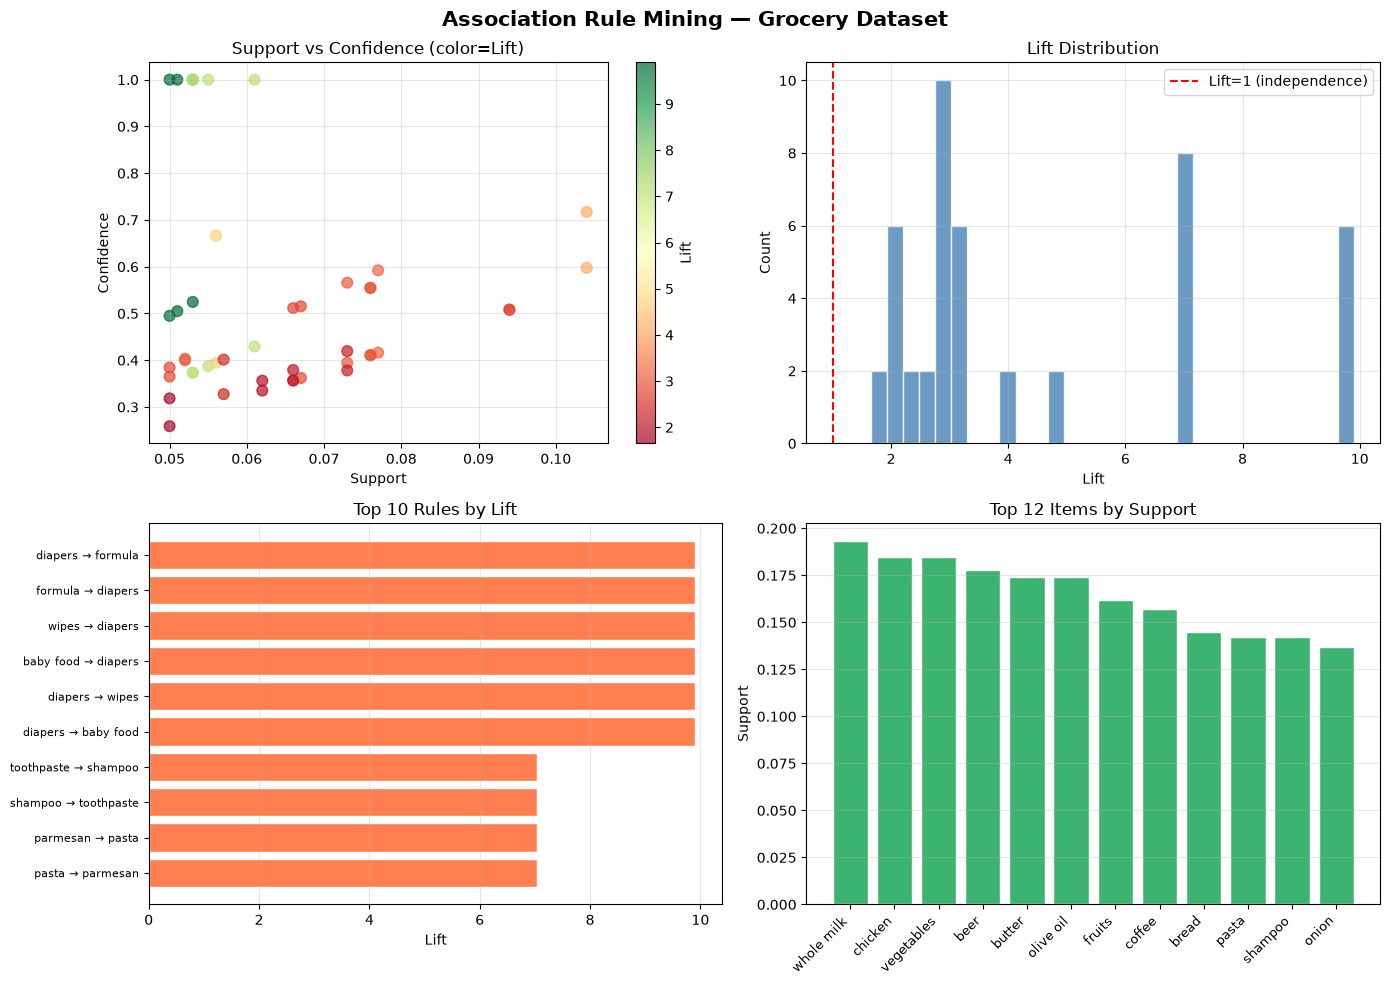

Plot saved.


In [13]:
# -----------------------------------------------------------
# Visualizations
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Association Rule Mining Grocery Dataset', fontsize=15, fontweight='bold')

# 1. Support vs Confidence scatter (colored by lift)
ax = axes[0, 0]
sc = ax.scatter(grocery_rules['support'], grocery_rules['confidence'],
                c=grocery_rules['lift'], cmap='RdYlGn', alpha=0.7, s=60)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Support vs Confidence (color=Lift)')
ax.grid(True, alpha=0.3)

# 2. Lift distribution
ax = axes[0, 1]
ax.hist(grocery_rules['lift'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Lift=1 (independence)')
ax.set_xlabel('Lift')
ax.set_ylabel('Count')
ax.set_title('Lift Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Top 10 rules by lift (horizontal bar)
ax = axes[1, 0]
top10 = grocery_rules.head(10).copy()
top10['rule'] = (top10['antecedents'].apply(lambda x: ', '.join(list(x))) +
                 ' → ' +
                 top10['consequents'].apply(lambda x: ', '.join(list(x))))
top10 = top10.sort_values('lift')
bars = ax.barh(range(len(top10)), top10['lift'], color='coral', edgecolor='white')
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['rule'], fontsize=8)
ax.set_xlabel('Lift')
ax.set_title('Top 10 Rules by Lift')
ax.grid(True, axis='x', alpha=0.3)

# 4. Item frequency
ax = axes[1, 1]
top_items = item_freq.head(12)
ax.bar(range(len(top_items)), top_items.values, color='mediumseagreen', edgecolor='white')
ax.set_xticks(range(len(top_items)))
ax.set_xticklabels(top_items.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Support')
ax.set_title('Top 12 Items by Support')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/association_rules_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved.")

## 10. E-commerce Recommendation Use Case

Association rules power **collaborative filtering at the item level** in e-commerce. When a user adds item $A$ to their cart, we recommend item $B$ if the rule $A \Rightarrow B$ has high lift and confidence.

### Recommendation strategies
| Strategy | Metric to optimize | When to use |
|---|---|---|
| Cross-sell | High lift | Suggest complementary items |
| Upsell | High confidence | Suggest premium version |
| Bundle deals | High support | Design product bundles |
| Cold-start | High leverage | Find non-obvious associations |

### Real-world considerations
- **Seasonality**: rules change across seasons → mine rules per time window
- **Recency weighting**: recent transactions matter more
- **Category constraints**: don't recommend competing brands
- **Inventory-aware**: suppress rules for out-of-stock consequents
- **Diversity**: avoid showing only obvious rules (bread→butter)

### Pipeline
```
Transaction DB → One-hot encode → FP-Growth → Filter rules
     ↓                                              ↓
New cart item  →  Lookup antecedent  →  Rank consequents by lift
                                              ↓
                                    Return top-K recommendations
```

In [14]:
# -----------------------------------------------------------
# E-commerce recommendation engine using association rules
# -----------------------------------------------------------

class AssociationRuleRecommender:
    """
    Item-based recommender using association rules.
    """
    def __init__(self, min_support=0.03, min_confidence=0.2, min_lift=1.1):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.min_lift = min_lift
        self.rules = None
        self.encoder = None
    
    def fit(self, transactions):
        self.encoder = TransactionEncoder()
        encoded = self.encoder.fit_transform(transactions)
        df = pd.DataFrame(encoded, columns=self.encoder.columns_)
        
        freq_items = fpgrowth(df, min_support=self.min_support,
                              use_colnames=True, max_len=4)
        self.rules = association_rules(
            freq_items,
            metric='confidence',
            min_threshold=self.min_confidence
        )
        self.rules = self.rules[
            self.rules['lift'] >= self.min_lift
        ].sort_values('lift', ascending=False)
        
        print(f"Fitted on {len(transactions)} transactions")
        print(f"Mined {len(freq_items)} frequent itemsets")
        print(f"Generated {len(self.rules)} rules")
        return self
    
    def recommend(self, cart_items, top_k=5, exclude_cart=True):
        """
        Given items in cart, return top-k recommended items.
        """
        cart_set = frozenset(cart_items)
        recommendations = {}
        
        for _, rule in self.rules.iterrows():
            antecedent = rule['antecedents']
            # Check if antecedent is subset of cart
            if antecedent.issubset(cart_set):
                for item in rule['consequents']:
                    if exclude_cart and item in cart_set:
                        continue
                    if item not in recommendations:
                        recommendations[item] = {
                            'lift': rule['lift'],
                            'confidence': rule['confidence'],
                            'support': rule['support'],
                            'triggered_by': set(antecedent)
                        }
                    else:
                        # Keep highest lift score
                        if rule['lift'] > recommendations[item]['lift']:
                            recommendations[item]['lift'] = rule['lift']
        
        # Sort by lift
        sorted_recs = sorted(recommendations.items(),
                             key=lambda x: x[1]['lift'], reverse=True)
        return sorted_recs[:top_k]


# Build and use the recommender
recommender = AssociationRuleRecommender(
    min_support=0.04,
    min_confidence=0.15,
    min_lift=1.1
)
recommender.fit(grocery_transactions)

# Test recommendations
test_carts = [
    ['whole milk', 'bread'],
    ['chicken', 'rice'],
    ['pasta', 'olive oil'],
    ['beer'],
    ['coffee', 'sugar'],
]

print("\n" + "="*60)
print("RECOMMENDATION ENGINE DEMO")
print("="*60)

for cart in test_carts:
    recs = recommender.recommend(cart, top_k=3)
    print(f"\nCart: {cart}")
    if recs:
        print("  Recommendations:")
        for item, metrics in recs:
            print(f"    -> {item:<20} "
                  f"lift={metrics['lift']:.2f}  "
                  f"conf={metrics['confidence']:.2f}  "
                  f"(triggered by: {metrics['triggered_by']})")
    else:
        print("  No recommendations found (try lower thresholds)")

Fitted on 1000 transactions
Mined 77 frequent itemsets
Generated 112 rules

RECOMMENDATION ENGINE DEMO

Cart: ['whole milk', 'bread']
  Recommendations:
    -> jam                  lift=6.90  conf=0.28  (triggered by: {'bread'})
    -> butter               lift=6.90  conf=0.28  (triggered by: {'bread'})
    -> eggs                 lift=2.46  conf=0.25  (triggered by: {'whole milk'})

Cart: ['chicken', 'rice']
  Recommendations:
    -> garlic               lift=4.32  conf=0.22  (triggered by: {'chicken'})
    -> onion                lift=4.32  conf=0.22  (triggered by: {'chicken'})
    -> vegetables           lift=3.63  conf=0.34  (triggered by: {'rice'})

Cart: ['pasta', 'olive oil']
  Recommendations:
    -> ground beef          lift=7.04  conf=0.32  (triggered by: {'pasta'})
    -> parmesan             lift=7.04  conf=0.39  (triggered by: {'pasta'})
    -> tomato sauce         lift=3.88  conf=0.35  (triggered by: {'pasta'})

Cart: ['beer']
  Recommendations:
    -> salsa             

In [15]:
# -----------------------------------------------------------
# Algorithm comparison summary
# -----------------------------------------------------------

comparison = pd.DataFrame({
    'Algorithm': ['Apriori', 'FP-Growth', 'ECLAT', 'SPADE', 'PrefixSpan', 'CHARM'],
    'Type': ['Itemset', 'Itemset', 'Itemset', 'Sequential', 'Sequential', 'Closed Itemset'],
    'DB Scans': ['Multiple (k)', '2', '1 (+joins)', '1', '1 (recursive)', '1'],
    'Data Format': ['Horizontal', 'FP-Tree', 'Vertical (tidsets)', 'Vertical (ID-lists)', 'Horizontal (projected)', 'Vertical (tidsets)'],
    'Candidate Gen': ['Yes', 'No', 'No', 'No', 'No', 'No'],
    'Output': ['All frequent', 'All frequent', 'All frequent', 'Sequences', 'Sequences', 'Closed only'],
    'Best For': ['Small sparse datasets', 'Large dense datasets', 'Dense, moderate memory', 'Customer journeys', 'Long sequences', 'Dense, compact output'],
})

print("Algorithm Comparison:")
print(comparison.to_string(index=False))

# Parameter sensitivity analysis
print("\n" + "="*60)
print("Support threshold sensitivity (FP-Growth on grocery data):")
print("="*60)
thresholds = [0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
for thresh in thresholds:
    fi = fpgrowth(grocery_df, min_support=thresh, use_colnames=True, max_len=3)
    r = association_rules(fi, metric='lift', min_threshold=1.0) if len(fi) > 0 else pd.DataFrame()
    print(f"  min_support={thresh:.2f}: {len(fi):4d} itemsets, {len(r):4d} rules")

Algorithm Comparison:
 Algorithm           Type      DB Scans            Data Format Candidate Gen       Output               Best For
   Apriori        Itemset  Multiple (k)             Horizontal           Yes All frequent  Small sparse datasets
 FP-Growth        Itemset             2                FP-Tree            No All frequent   Large dense datasets
     ECLAT        Itemset    1 (+joins)     Vertical (tidsets)            No All frequent Dense, moderate memory
     SPADE     Sequential             1    Vertical (ID-lists)            No    Sequences      Customer journeys
PrefixSpan     Sequential 1 (recursive) Horizontal (projected)            No    Sequences         Long sequences
     CHARM Closed Itemset             1     Vertical (tidsets)            No  Closed only  Dense, compact output

Support threshold sensitivity (FP-Growth on grocery data):
  min_support=0.02:  154 itemsets,  398 rules
  min_support=0.03:  109 itemsets,  224 rules
  min_support=0.05:   53 itemsets, 

## Additional Learning Resources

### Foundational Papers

1. **Apriori**: Agrawal, R., & Srikant, R. (1994). *Fast algorithms for mining association rules*. VLDB 1994. [PDF](http://www.vldb.org/conf/1994/P487.PDF)

2. **FP-Growth**: Han, J., Pei, J., & Yin, Y. (2000). *Mining frequent patterns without candidate generation*. SIGMOD 2000. [DOI](https://doi.org/10.1145/342009.335372)

3. **ECLAT**: Zaki, M. J., Parthasarathy, S., Ogihara, M., & Li, W. (1997). *New algorithms for fast discovery of association rules*. KDD 1997.

4. **SPADE**: Zaki, M. J. (2001). *SPADE: An efficient algorithm for mining frequent sequences*. Machine Learning, 42(1-2), 31-60. [DOI](https://doi.org/10.1023/A:1007652502315)

5. **PrefixSpan**: Pei, J., Han, J., Mortazavi-Asl, B., et al. (2001). *PrefixSpan: Mining sequential patterns efficiently by prefix-projected pattern growth*. ICDE 2001.

6. **CHARM**: Zaki, M. J., & Hsiao, C.-J. (2002). *CHARM: An efficient algorithm for closed itemset mining*. SDM 2002.

### Libraries and Tools

- **mlxtend**: [rasbt.github.io/mlxtend](http://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/) Apriori, FP-Growth, association_rules
- **PyFIM** (fim): C-based, fastest Python implementation `pip install fim`
- **SPMF**: Java-based comprehensive library with 120+ pattern mining algorithms [philippe-fournier-viger.com/spmf](http://www.philippe-fournier-viger.com/spmf/)
- **Spark MLlib**: `pyspark.ml.fpm.FPGrowth` for distributed mining at scale

### Courses and Tutorials

- **Mining Massive Datasets** (Stanford, free): [mmds.org](http://www.mmds.org) Chapter 6 covers frequent itemsets
- **Data Mining: Concepts and Techniques** Han, Kamber & Pei (3rd ed.), Chapters 6-7
- **Coursera Data Mining Specialization** (UIUC): Pattern discovery course by Jiawei Han
- **mlxtend documentation**: Complete worked examples with real datasets

### Datasets for Practice

- **Groceries dataset**: [Kaggle](https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset) 38,765 transactions, 167 items
- **Online Retail II**: [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Online+Retail+II) 1M+ e-commerce transactions
- **Instacart Market Basket**: [Kaggle](https://www.kaggle.com/c/instacart-market-basket-analysis) 3M+ orders
- **RETAIL dataset**: [FIMI repository](http://fimi.uantwerpen.be/data/) Benchmark dataset used in research

### Further Topics

- **Quantitative association rules**: handling numeric attributes
- **Multi-level association rules**: mining across item taxonomies (bread → bakery)
- **Rare itemset mining**: finding low-support but high-value patterns
- **Negative associations**: $A \Rightarrow \neg B$ (buying A means NOT buying B)
- **Temporal association rules**: time-aware patterns
- **Interestingness measures survey**: Geng & Hamilton (2006) review of 20+ metrics beyond lift